In [235]:
import pandas as pd
import ast
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import umap
from sklearn.model_selection import train_test_split

sns.set(style="whitegrid")


In [198]:
tracks = pd.read_csv("./data/tracks.tsv", sep="\t")
echonest = pd.read_csv("./data/echonest_features.tsv", sep="\t")
spectral = pd.read_csv("./data/spectral_features.tsv", sep="\t")
genres = pd.read_csv("./data/genres.csv")

In [199]:
def clean_cols(df):
    df.columns = df.columns.str.lower().str.replace(" ", "_")
    return df

tracks = clean_cols(tracks)
echonest = clean_cols(echonest)
spectral = clean_cols(spectral)
genres = clean_cols(genres)


In [200]:
# Merge tracks + echonest
df = pd.merge(tracks, echonest, on="track_id", how="outer")

# Merge avec spectral
df = pd.merge(df, spectral, on="track_id", how="outer")

In [201]:
df.shape



(100882, 43)

In [202]:
df.describe(include="all").transpose().head(30)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
track_id,100882.0,NaN,NaN,NaN,83848.443449,41939.264125,11870.0,47333.25,83019.5,121348.75,155320.0
album_title,99084,13212,microSong Entries,310,NaN,NaN,NaN,NaN,NaN,NaN,NaN
album_tracks,99995.0,NaN,NaN,NaN,19.908645,40.510849,-1.0,7.0,11.0,18.0,652.0
artist_latitude,40207.0,NaN,NaN,NaN,39.967832,18.766913,-45.874501,39.271398,41.823989,50.079079,67.286005
artist_longitude,40207.0,NaN,NaN,NaN,-35.443236,65.670545,-157.526855,-78.868915,-72.669067,5.007986,175.277
artist_name,99995,15491,Kosta T,745,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,99995.0,NaN,NaN,NaN,278.034522,294.940279,0.0,151.0,218.0,307.0,11030.0
favorites,99995.0,NaN,NaN,NaN,3.239962,13.863871,0.0,0.0,1.0,3.0,1482.0
genre_top,44633,16,Rock,12085,NaN,NaN,NaN,NaN,NaN,NaN,NaN
genres,99995,4652,[21],2527,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [203]:
(df.isna().sum() / len(df) * 100).head(30)


track_id                           0.000000
album_title                        1.782280
album_tracks                       0.879245
artist_latitude                   60.144525
artist_longitude                  60.144525
artist_name                        0.879245
duration                           0.879245
favorites                          0.879245
genre_top                         55.757221
genres                             0.879245
genres_all                         0.879245
interest                           0.879245
listens                            0.879245
title                              0.880236
acousticness                      88.660019
danceability                      88.678853
energy                            88.660019
instrumentalness                  88.660019
liveness                          88.660019
speechiness                       88.808707
tempo                             88.660019
valence                           88.680835
spectral_bandwidth_kurtosis_01  

In [204]:
df.duplicated(subset=["track_id"]).sum()


np.int64(0)

In [205]:
df["genre_top"].value_counts(dropna=False)


genre_top
NaN                    56249
Rock                   12085
Experimental            9752
Electronic              8769
Hip-Hop                 3334
Folk                    2375
Pop                     2235
Instrumental            2003
International           1256
Classical               1129
Old-Time / Historic      491
Jazz                     484
Spoken                   323
Country                  163
Soul-RnB                 131
Blues                     79
Easy Listening            24
Name: count, dtype: int64

In [206]:
# Dicos à partir de genres.csv
id2parent = genres.set_index("genre_id")["genre_parent_id"].to_dict()
id2title  = genres.set_index("genre_id")["genre_title"].to_dict()
title2id  = genres.set_index("genre_title")["genre_id"].to_dict()

def get_root_title_from_id(gid):
    """À partir d'un genre_id (ex: 21), remonte jusqu'au genre racine et renvoie son titre."""
    if pd.isna(gid):
        return None
    try:
        gid = int(gid)
    except Exception:
        return None

    seen = set()
    while True:
        if gid in seen:  # sécurité anti-boucle
            return id2title.get(gid)
        seen.add(gid)

        parent = id2parent.get(gid)
        if parent is None or pd.isna(parent):
            # on est au niveau racine
            return id2title.get(gid)
        try:
            gid = int(parent)
        except Exception:
            return id2title.get(gid)

def first_id_to_root_title(s):
    """
    s est une string du type "[21, 33]" ou "[]".
    On prend le premier ID et on renvoie le *genre racine* correspondant.
    """
    if isinstance(s, float) and math.isnan(s):
        return None
    if not isinstance(s, str):
        return None
    try:
        ids = ast.literal_eval(s)   # -> [21, 33]
        if not ids:
            return None
        first_id = ids[0]
        return get_root_title_from_id(first_id)
    except Exception:
        return None

# colonnes temporaires pour l’imputation
df["genre_top_from_genres"] = df["genres"].apply(first_id_to_root_title)
df["genre_top_from_genres_all"] = df["genres_all"].apply(first_id_to_root_title)

print("Taux de NaN genre_top AVANT :", df["genre_top"].isna().mean())

# imputation de genre_top avec les genres *racines*
df["genre_top"] = df["genre_top"].fillna(df["genre_top_from_genres"])
df["genre_top"] = df["genre_top"].fillna(df["genre_top_from_genres_all"])

print("Taux de NaN genre_top APRES  :", df["genre_top"].isna().mean())

# on enlève les colonnes temporaires
df = df.drop(columns=["genre_top_from_genres", "genre_top_from_genres_all"])


Taux de NaN genre_top AVANT : 0.5575722130806289
Taux de NaN genre_top APRES  : 0.029985527646160862


In [207]:
nan_ratio = df.isna().mean().sort_values(ascending=False)
nan_ratio


speechiness                       0.888087
valence                           0.886808
danceability                      0.886789
instrumentalness                  0.886600
energy                            0.886600
tempo                             0.886600
liveness                          0.886600
acousticness                      0.886600
artist_latitude                   0.601445
artist_longitude                  0.601445
genre_top                         0.029986
album_title                       0.017823
title                             0.008802
favorites                         0.008792
genres_all                        0.008792
artist_name                       0.008792
duration                          0.008792
album_tracks                      0.008792
genres                            0.008792
spectral_bandwidth_skew_01        0.008792
interest                          0.008792
listens                           0.008792
spectral_bandwidth_kurtosis_01    0.008792
spectral_ba

In [208]:
low_thresh = 0.01   # <1% NaN → imputation
high_thresh = 0.50  # >50% NaN → potentiellement à drop

cols_low_nan = nan_ratio[nan_ratio < low_thresh].index.tolist()
cols_high_nan = nan_ratio[nan_ratio > high_thresh].index.tolist()

print("Colonnes <1% NaN :", len(cols_low_nan))
print("Colonnes >50% NaN :", len(cols_high_nan))
cols_low_nan, cols_high_nan


Colonnes <1% NaN : 31
Colonnes >50% NaN : 10


(['title',
  'favorites',
  'genres_all',
  'artist_name',
  'duration',
  'album_tracks',
  'genres',
  'spectral_bandwidth_skew_01',
  'interest',
  'listens',
  'spectral_bandwidth_kurtosis_01',
  'spectral_bandwidth_max_01',
  'spectral_bandwidth_mean_01',
  'spectral_bandwidth_median_01',
  'spectral_bandwidth_min_01',
  'spectral_centroid_std_01',
  'spectral_bandwidth_std_01',
  'spectral_centroid_kurtosis_01',
  'spectral_centroid_max_01',
  'spectral_centroid_mean_01',
  'spectral_centroid_median_01',
  'spectral_centroid_min_01',
  'spectral_centroid_skew_01',
  'spectral_rolloff_median_01',
  'spectral_rolloff_kurtosis_01',
  'spectral_rolloff_max_01',
  'spectral_rolloff_mean_01',
  'spectral_rolloff_skew_01',
  'spectral_rolloff_min_01',
  'spectral_rolloff_std_01',
  'track_id'],
 ['speechiness',
  'valence',
  'danceability',
  'instrumentalness',
  'energy',
  'tempo',
  'liveness',
  'acousticness',
  'artist_latitude',
  'artist_longitude'])

In [209]:
echonest_cols = [
    "acousticness", "danceability", "energy", "instrumentalness",
    "liveness", "speechiness", "tempo", "valence"
]

# colonnes qu’on protège même si beaucoup de NaN
protected_cols = set(echonest_cols + ["genre_top"])

# colonnes très manquantes à drop (ex: artist_latitude, artist_longitude)
high_missing_to_drop = [c for c in cols_high_nan if c not in protected_cols]

high_missing_to_drop


['artist_latitude', 'artist_longitude']

In [210]:
df_clean = df.drop(columns=high_missing_to_drop).copy()

nan_ratio_clean = df_clean.isna().mean()
cols_low_nan_clean = nan_ratio_clean[nan_ratio_clean < low_thresh].index

for col in cols_low_nan_clean:
    if df_clean[col].dtype != "object":
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())
    else:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

df_clean.isna().mean().sort_values(ascending=False).head(20)


speechiness         0.888087
valence             0.886808
danceability        0.886789
instrumentalness    0.886600
liveness            0.886600
acousticness        0.886600
energy              0.886600
tempo               0.886600
genre_top           0.029986
album_title         0.017823
genres_all          0.000000
favorites           0.000000
genres              0.000000
album_tracks        0.000000
artist_name         0.000000
track_id            0.000000
duration            0.000000
listens             0.000000
interest            0.000000
title               0.000000
dtype: float64

In [211]:
# Sans echonest
df_no_echonest = df_clean.drop(columns=[c for c in echonest_cols if c in df_clean.columns])
print("df_no_echonest:", df_no_echonest.shape)

# Avec echonest
df_with_echonest = df_clean.copy()
print("df_with_echonest:", df_with_echonest.shape)


df_no_echonest: (100882, 33)
df_with_echonest: (100882, 41)


In [212]:
df_no_echonest_clf = df_no_echonest[~df_no_echonest["genre_top"].isna()].copy()
df_with_echonest_clf = df_with_echonest[~df_with_echonest["genre_top"].isna()].copy()

print("Classification sans echonest:", df_no_echonest_clf.shape)
print("Classification avec echonest:", df_with_echonest_clf.shape)


Classification sans echonest: (97857, 33)
Classification avec echonest: (97857, 41)


In [213]:
text_cols = ["album_title", "title", "artist_name"]

df_no_echonest_clf = df_no_echonest_clf.drop(columns=text_cols + ["track_id"], errors="ignore")
df_with_echonest_clf = df_with_echonest_clf.drop(columns=text_cols + ["track_id"], errors="ignore")

print("df_no_echonest_clf:", df_no_echonest_clf.shape)
print("df_with_echonest_clf:", df_with_echonest_clf.shape)


df_no_echonest_clf: (97857, 29)
df_with_echonest_clf: (97857, 37)


In [214]:
df_no_echonest_clf_fe = df_no_echonest_clf.copy()
df_with_echonest_clf_fe = df_with_echonest_clf.copy()


In [215]:
log_vars = ["listens", "interest", "favorites"]

for col in log_vars:
    if col in df_no_echonest_clf_fe.columns:
        df_no_echonest_clf_fe[col + "_log1p"] = np.log1p(df_no_echonest_clf_fe[col])
    if col in df_with_echonest_clf_fe.columns:
        df_with_echonest_clf_fe[col + "_log1p"] = np.log1p(df_with_echonest_clf_fe[col])

In [216]:
def add_popularity_score_log(df):
    # log1p transform
    df["listens_log"] = np.log1p(df["listens"])
    df["interest_log"] = np.log1p(df["interest"])
    df["favorites_log"] = np.log1p(df["favorites"])

    # normalisation min-max
    for col in ["listens_log", "interest_log", "favorites_log"]:
        df[col + "_norm"] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())

    # moyenne après normalisation
    df["popularity_score"] = df[[
        "listens_log_norm",
        "interest_log_norm",
        "favorites_log_norm"
    ]].mean(axis=1)

    return df

df_no_echonest_clf_fe = add_popularity_score_log(df_no_echonest_clf_fe)
df_with_echonest_clf_fe = add_popularity_score_log(df_with_echonest_clf_fe)


In [217]:
bins = [0, 150, 300, df_no_echonest_clf_fe["duration"].max()]
labels = ["short", "medium", "long"]

df_no_echonest_clf_fe["duration_bin"] = pd.cut(
    df_no_echonest_clf_fe["duration"], bins=bins, labels=labels, include_lowest=True
)

df_with_echonest_clf_fe["duration_bin"] = pd.cut(
    df_with_echonest_clf_fe["duration"], bins=bins, labels=labels, include_lowest=True
)


In [218]:
# produit energy*danceability
if all(c in df_with_echonest_clf_fe.columns for c in ["energy", "danceability"]):
    df_with_echonest_clf_fe["energy_x_danceability"] = (
        df_with_echonest_clf_fe["energy"] * df_with_echonest_clf_fe["danceability"]
    )

# ratio acousticness/instrumentalness
if all(c in df_with_echonest_clf_fe.columns for c in ["acousticness", "instrumentalness"]):
    df_with_echonest_clf_fe["acoustic_instrumental_ratio"] = (
        df_with_echonest_clf_fe["acousticness"] / (df_with_echonest_clf_fe["instrumentalness"] + 1e-6)
    )

# log tempo
if "tempo" in df_with_echonest_clf_fe.columns:
    df_with_echonest_clf_fe["tempo_log1p"] = np.log1p(df_with_echonest_clf_fe["tempo"])


c:\Users\cyril\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\cyril\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


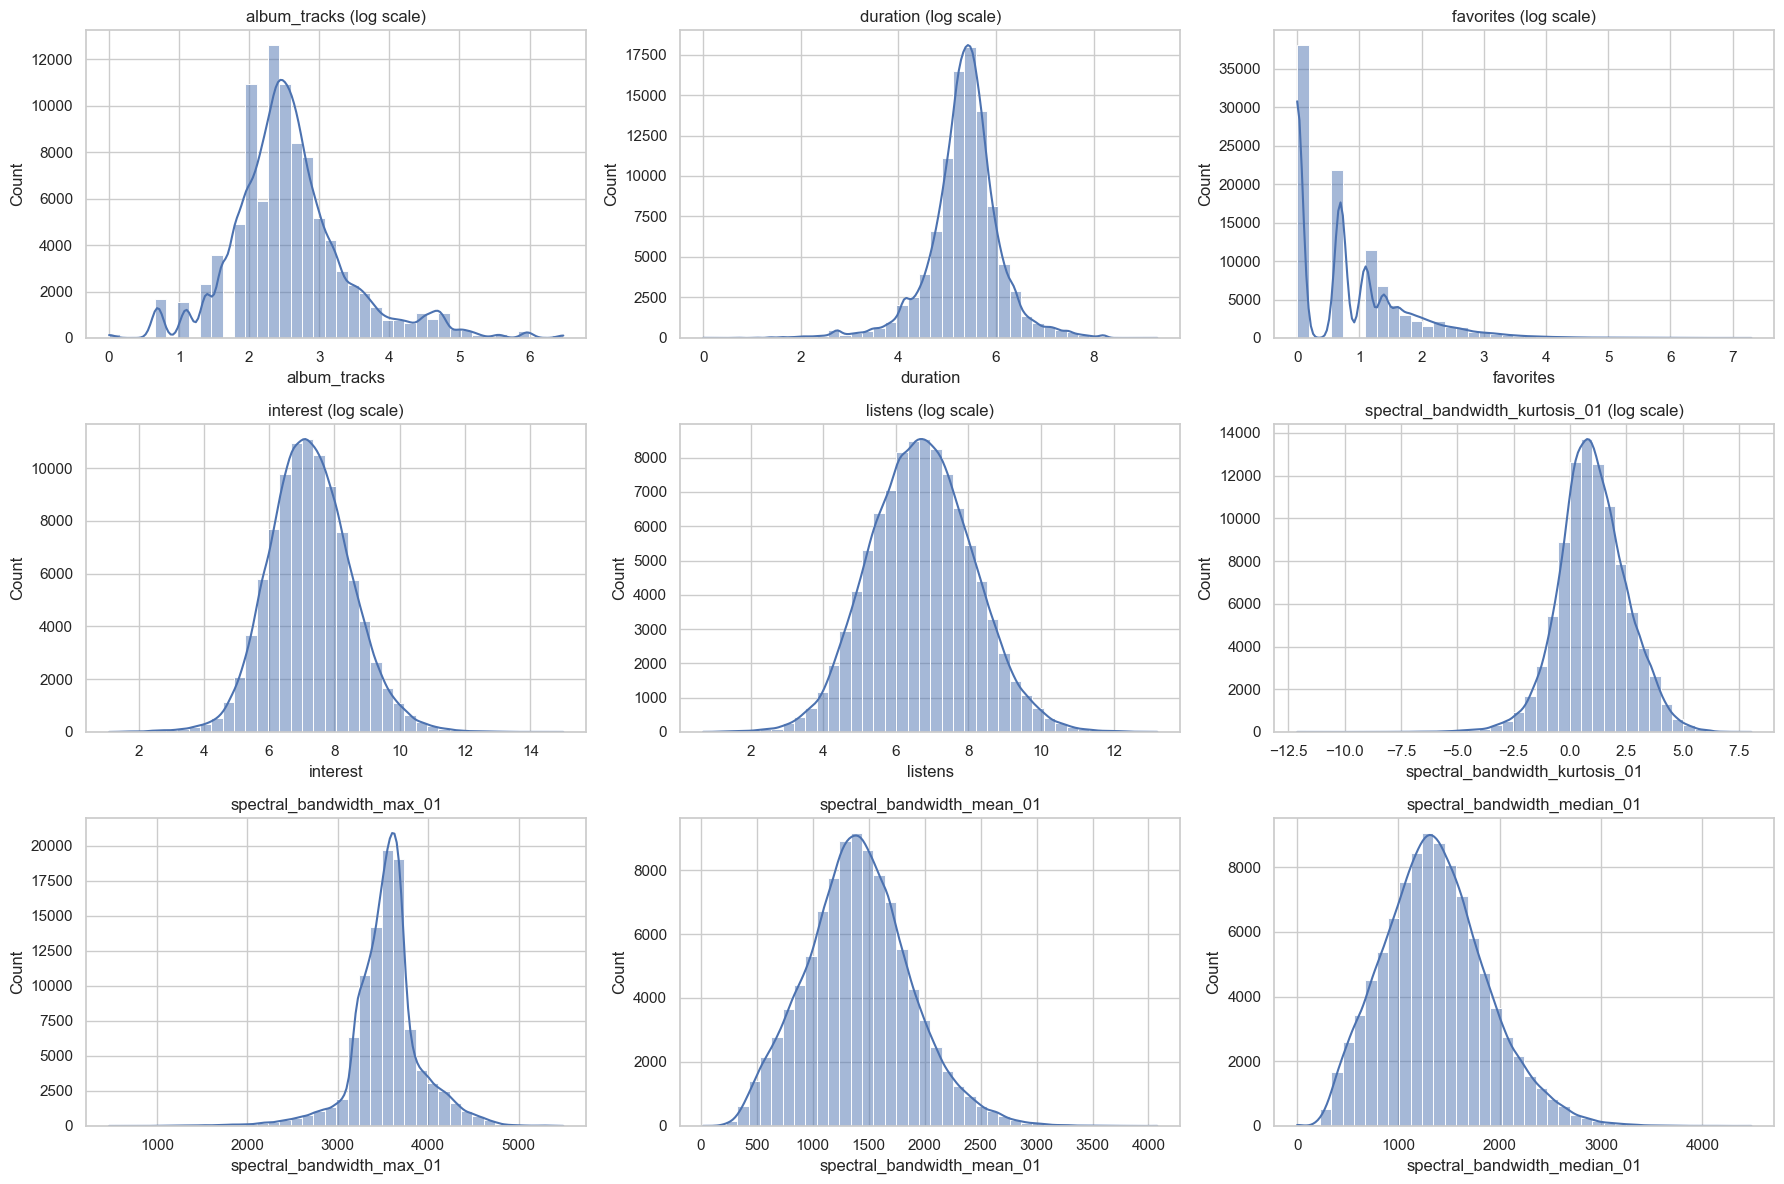

In [219]:
def plot_numeric_distributions(df, cols, n_cols=3, bins=40):
    n = len(cols)
    n_rows = int(np.ceil(n / n_cols))
    plt.figure(figsize=(6*n_cols, 4*n_rows))

    for i, col in enumerate(cols):
        data = df[col].dropna()

        # détecter skew
        skewness = data.skew()

        plt.subplot(n_rows, n_cols, i+1)

        # si skew > 2 → affichage en log
        if skewness > 2:
            sns.histplot(np.log1p(data), bins=bins, kde=True)
            plt.title(f"{col} (log scale)")
        else:
            sns.histplot(data, bins=bins, kde=True)
            plt.title(col)

    plt.tight_layout()
    plt.show()

numeric_cols = df_no_echonest_clf_fe.select_dtypes(include=["float64", "int64"]).columns.tolist()

# on enlève track_id, norms, etc.
numeric_cols = [c for c in numeric_cols 
                if not c.endswith("_norm")
                and c not in ["track_id"]]

plot_numeric_distributions(df_no_echonest_clf_fe, numeric_cols[:9])


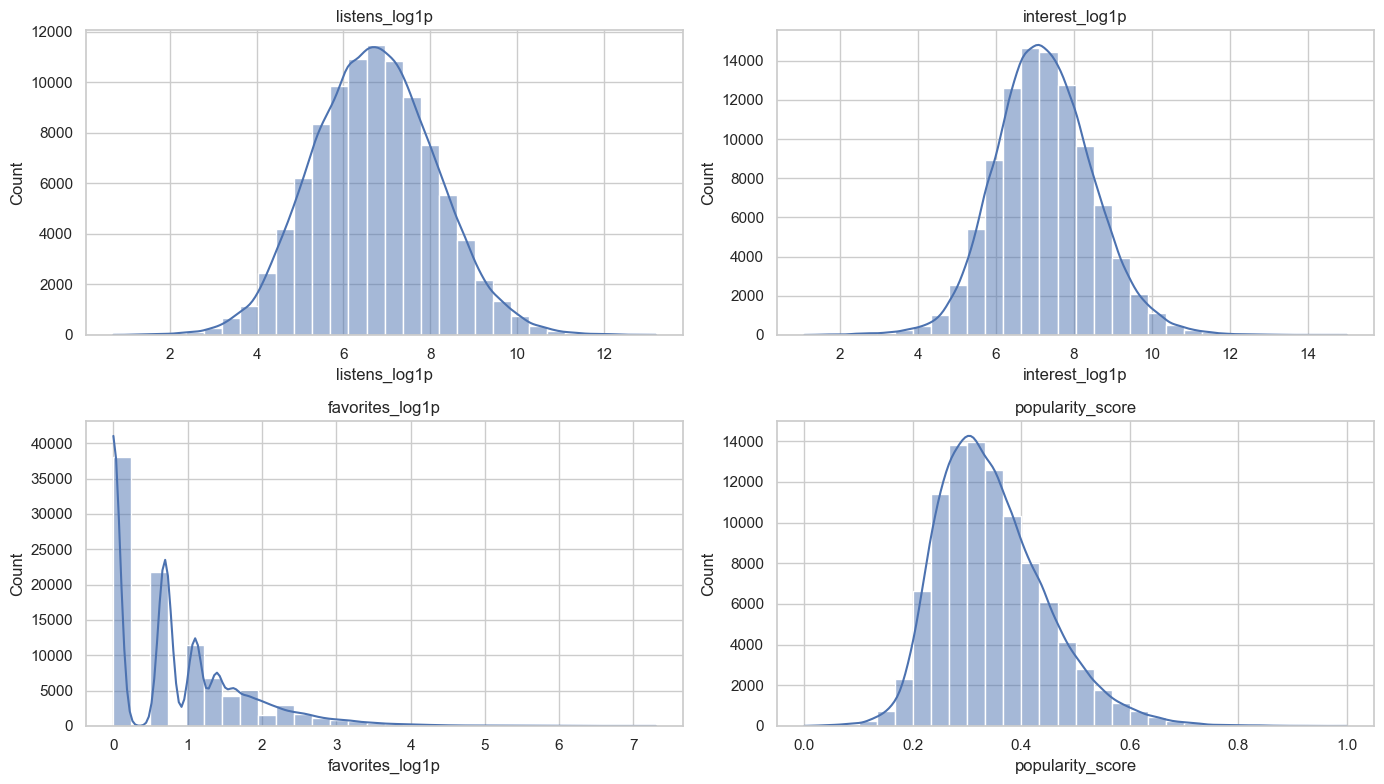

In [220]:
cols_pop = ["listens_log1p", "interest_log1p", "favorites_log1p", "popularity_score"]

plt.figure(figsize=(14, 8))
for i, col in enumerate(cols_pop):
    if col in df_no_echonest_clf_fe.columns:
        plt.subplot(2, 2, i+1)
        sns.histplot(df_no_echonest_clf_fe[col], kde=True, bins=30)
        plt.title(col)
plt.tight_layout()
plt.show()


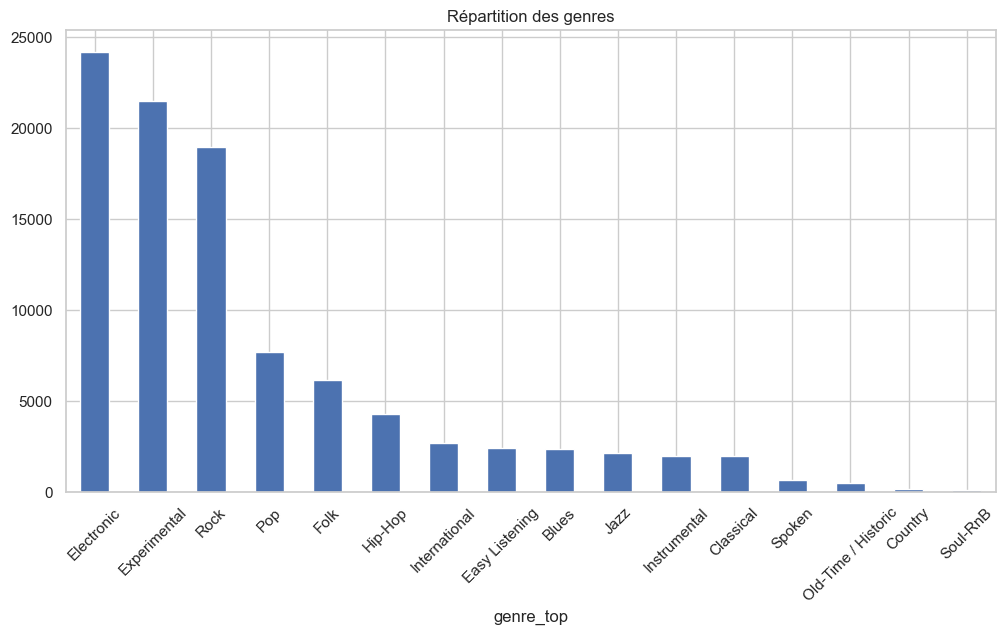

In [221]:
plt.figure(figsize=(12, 6))
df_no_echonest_clf_fe["genre_top"].value_counts().plot(kind="bar")
plt.title("Répartition des genres")
plt.xticks(rotation=45)
plt.show()


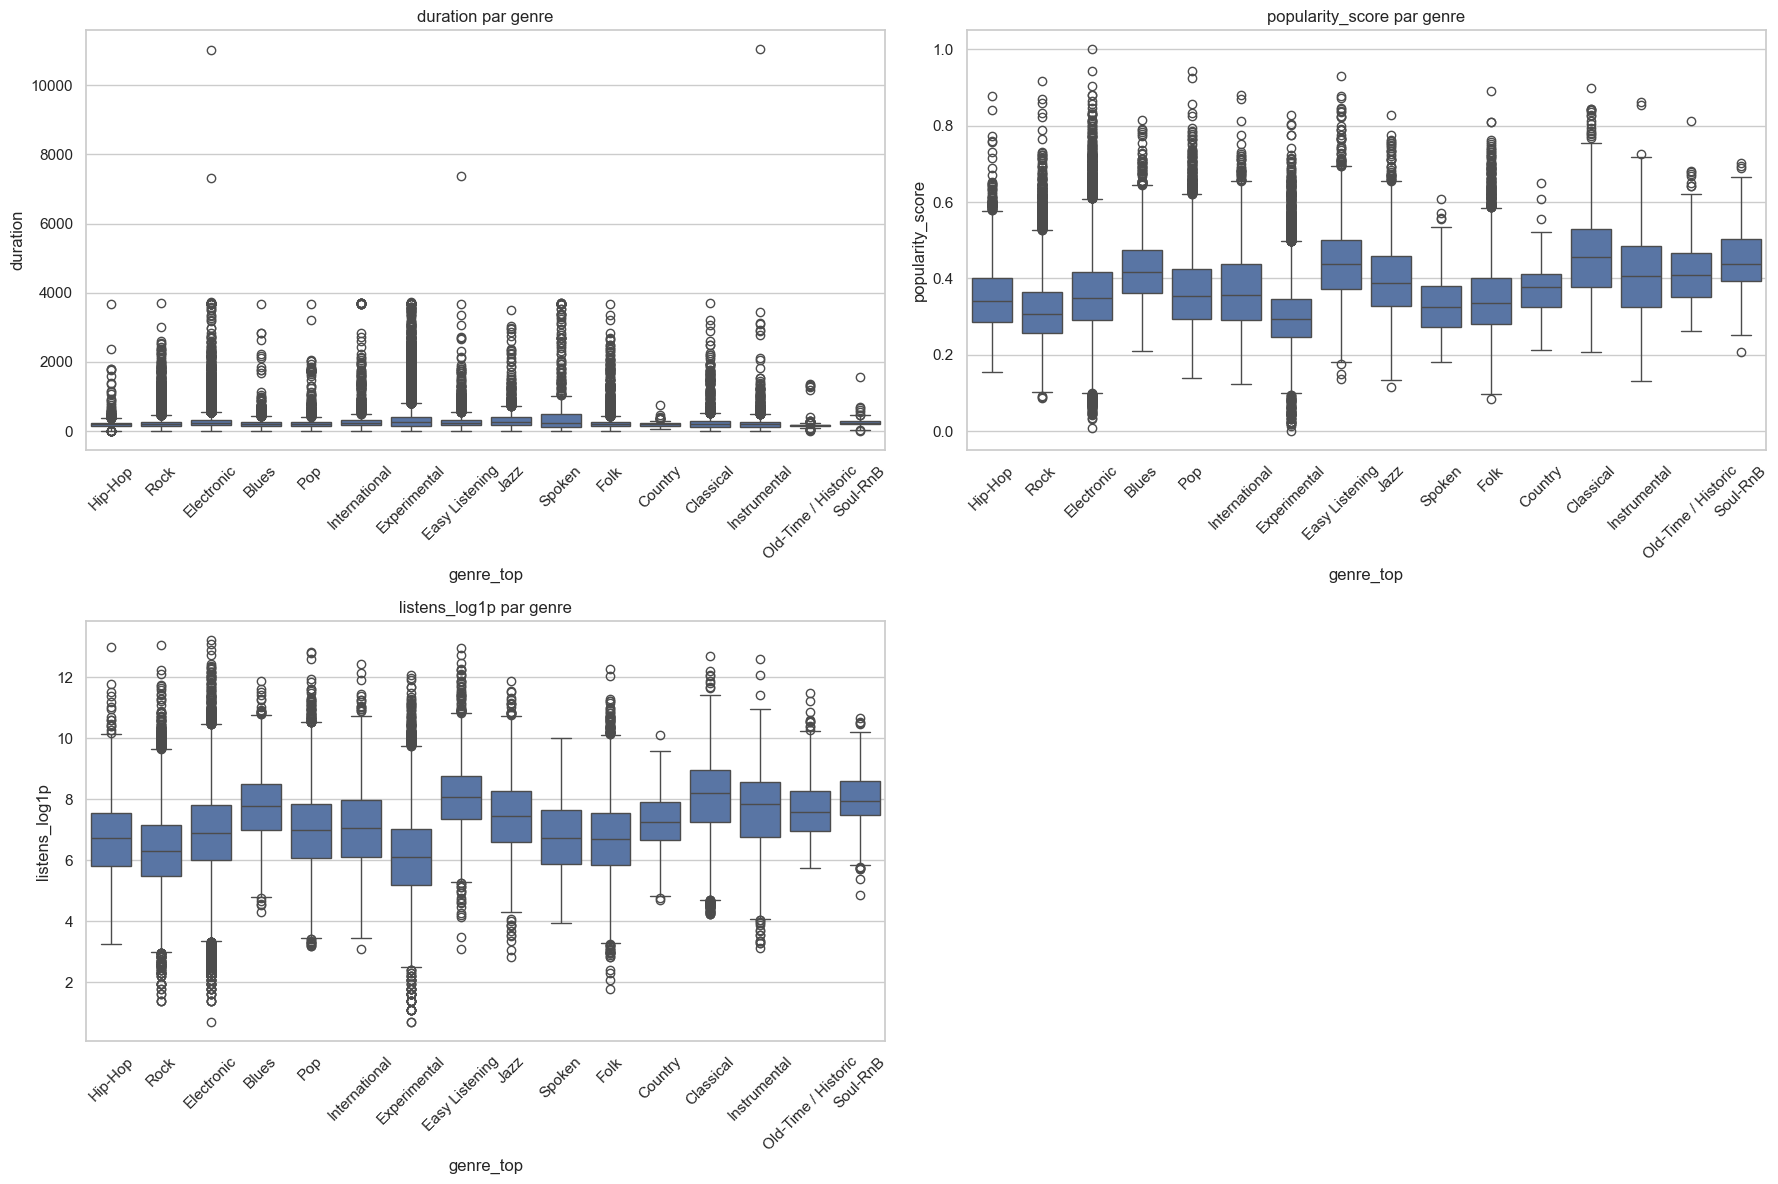

In [222]:
plt.figure(figsize=(18, 12))

cols_to_compare = ["duration", "popularity_score", "listens_log1p"]

for i, col in enumerate(cols_to_compare):
    plt.subplot(2, 2, i+1)
    sns.boxplot(data=df_no_echonest_clf_fe, x="genre_top", y=col)
    plt.xticks(rotation=45)
    plt.title(f"{col} par genre")
plt.tight_layout()
plt.show()


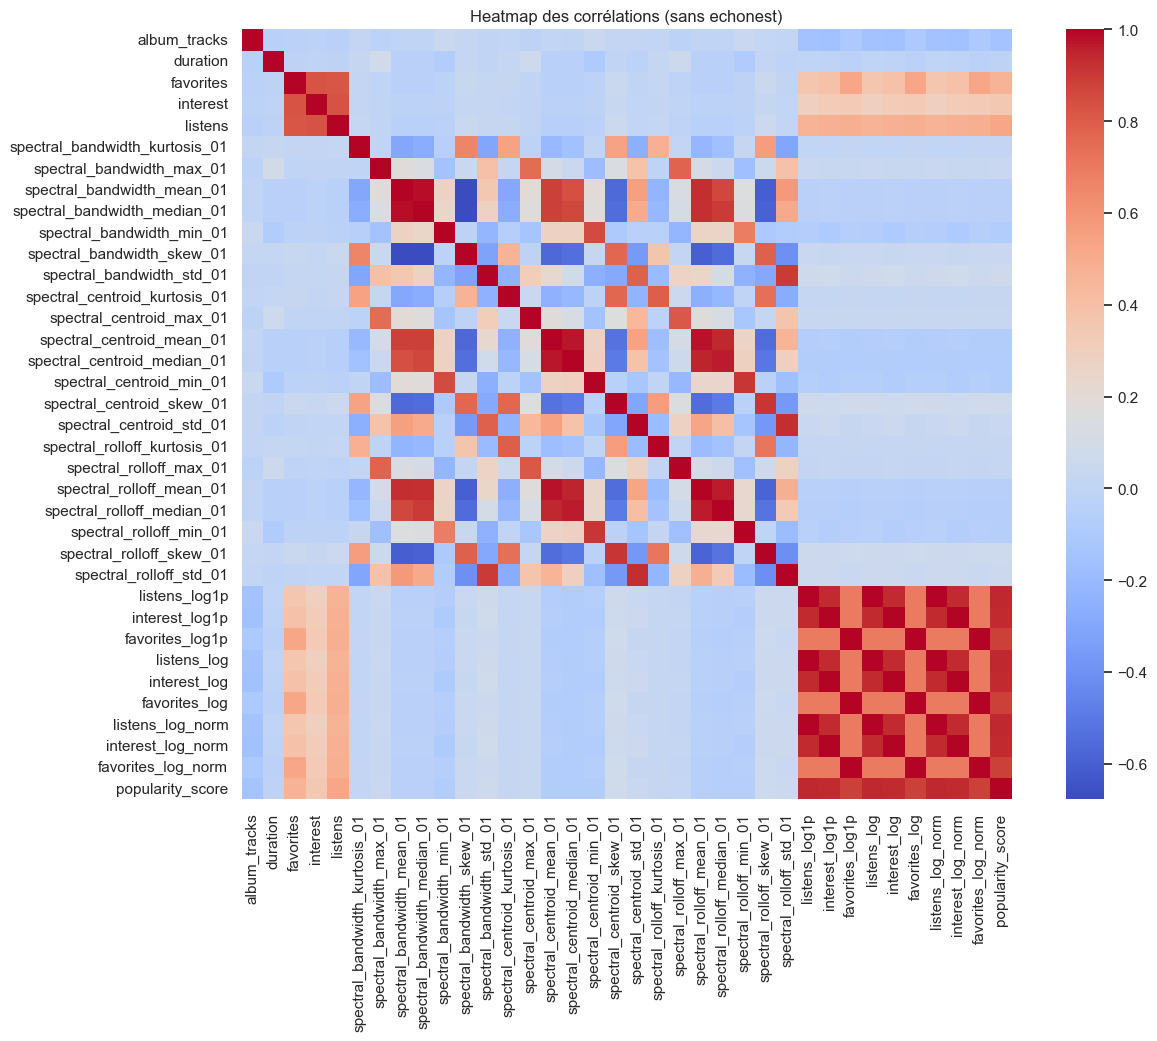

In [223]:
plt.figure(figsize=(14, 10))
sns.heatmap(
    df_no_echonest_clf_fe.corr(numeric_only=True),
    cmap="coolwarm",
    square=True
)
plt.title("Heatmap des corrélations (sans echonest)")
plt.show()


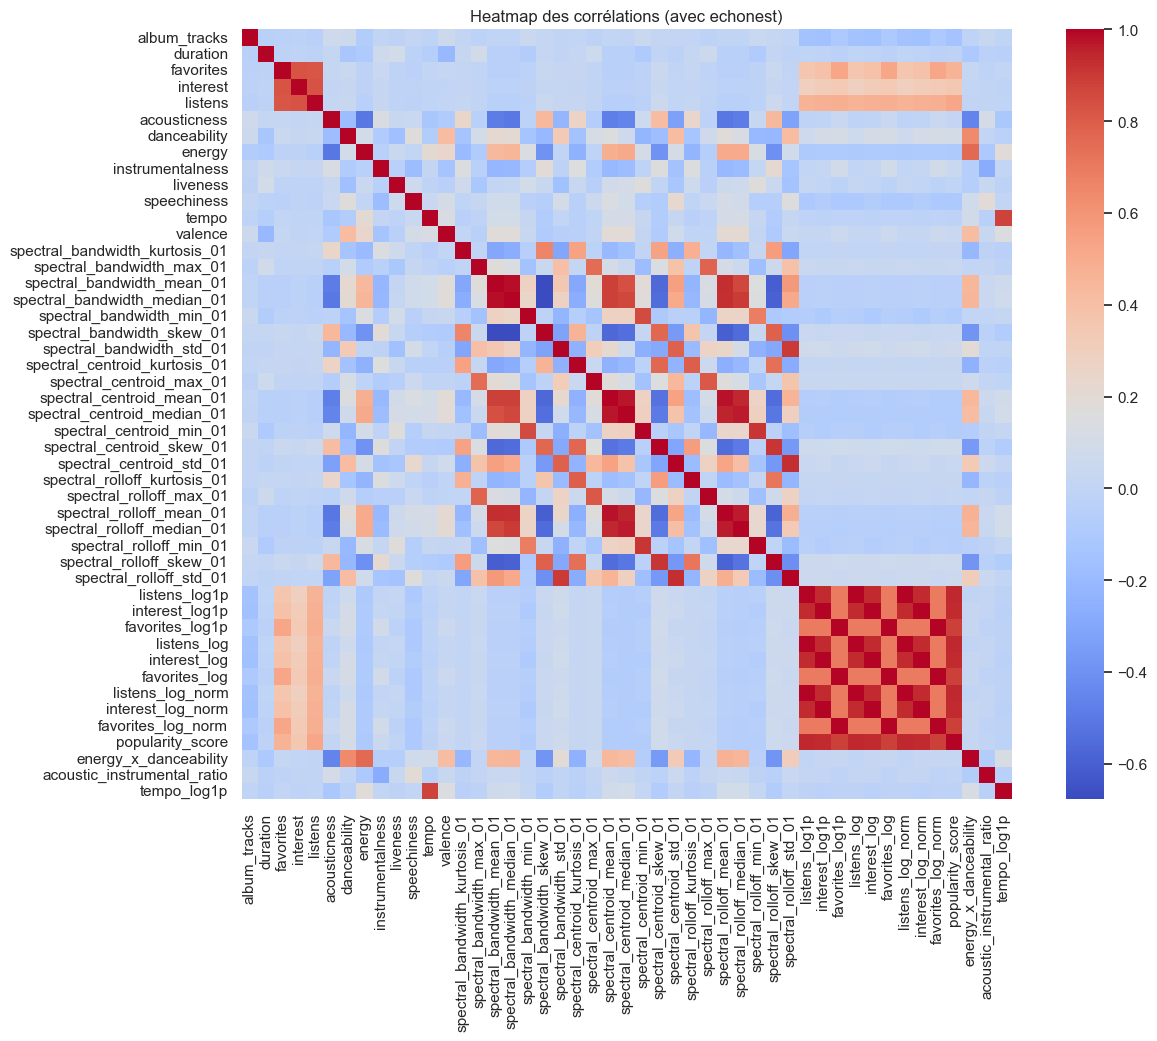

In [224]:
plt.figure(figsize=(14, 10))
sns.heatmap(
    df_with_echonest_clf_fe.corr(numeric_only=True),
    cmap="coolwarm",
    square=True
)
plt.title("Heatmap des corrélations (avec echonest)")
plt.show()


c:\Users\cyril\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


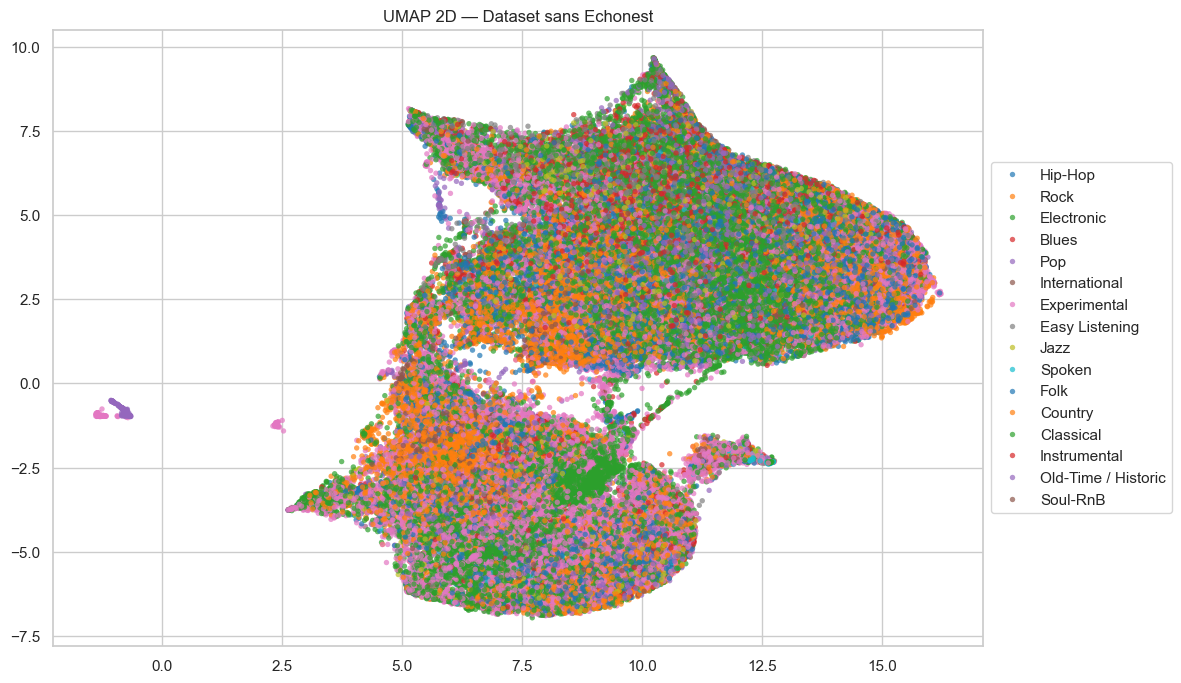

In [227]:
# Colonnes numériques
num_cols = df_no_echonest_clf_fe.select_dtypes(include=["float64", "int64"]).columns.tolist()
num_cols = [c for c in num_cols if c not in ["track_id"]]

X = df_no_echonest_clf_fe[num_cols]
y = df_no_echonest_clf_fe["genre_top"]

# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# UMAP 2D
umap_model = umap.UMAP(
    n_neighbors=25,
    min_dist=0.1,
    n_components=2,
    metric="euclidean",
    random_state=42
)
X_umap = umap_model.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=X_umap[:, 0],
    y=X_umap[:, 1],
    hue=y,
    palette="tab10",
    s=15, alpha=0.7,
    linewidth=0
)

plt.title("UMAP 2D — Dataset sans Echonest")
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.show()

In [228]:
macro_mapping = {
    "Classical": "Classical/Jazz",
    "Jazz": "Classical/Jazz",

    "Rock": "Rock/Pop",
    "Pop": "Rock/Pop",
    "Soul-RnB": "Rock/Pop",

    "Electronic": "Electronic",

    "Folk": "Folk/Country/Blues",
    "Blues": "Folk/Country/Blues",
    "Country": "Folk/Country/Blues",

    "Experimental": "Experimental/Instrumental/Ambient",
    "Instrumental": "Experimental/Instrumental/Ambient",
    "Ambient": "Experimental/Instrumental/Ambient",
    "Spoken": "Experimental/Instrumental/Ambient",
    "International": "Experimental/Instrumental/Ambient",
    "Easy Listening": "Experimental/Instrumental/Ambient",
    "Old-Time / Historic": "Experimental/Instrumental/Ambient",
}


In [229]:
drop_cols = [
    "track_id", "genre_top", "duration_bin", "subset", "subset_ord",
    "split", "is_train_split", "album_title", "title", "artist_name"
]

# on enlève aussi les versions normalisées doublons
drop_cols += [c for c in df_no_echonest_clf_fe.columns if c.endswith("_norm")]

# pour éviter les erreurs, errors='ignore'
df_no_echo = df_no_echonest_clf_fe.drop(columns=drop_cols, errors="ignore")
df_with_echo = df_with_echonest_clf_fe.drop(columns=drop_cols, errors="ignore")


In [230]:
# Task 1 (genres racines)
y_T1 = df_no_echonest_clf_fe["genre_top"]

# Task 2 (macro-genres)
y_T2 = df_no_echonest_clf_fe["genre_top"].map(macro_mapping)


In [231]:
y_T1_echo = df_with_echonest_clf_fe["genre_top"]
y_T2_echo = df_with_echonest_clf_fe["genre_top"].map(macro_mapping)


In [232]:
X_no_echo_T1 = df_no_echo.copy()
X_with_echo_T1 = df_with_echo.copy()

X_no_echo_T2 = df_no_echo.copy()
X_with_echo_T2 = df_with_echo.copy()


In [233]:
print("Task 1 — NO echo:", X_no_echo_T1.shape, y_T1.shape)
print("Task 1 — WITH echo:", X_with_echo_T1.shape, y_T1_echo.shape)

print("Task 2 — NO echo:", X_no_echo_T2.shape, y_T2.shape)
print("Task 2 — WITH echo:", X_with_echo_T2.shape, y_T2_echo.shape)


Task 1 — NO echo: (97857, 35) (97857,)
Task 1 — WITH echo: (97857, 46) (97857,)
Task 2 — NO echo: (97857, 35) (97857,)
Task 2 — WITH echo: (97857, 46) (97857,)


In [236]:
# Base pour le split maître
X = X_no_echo_T1
y = y_T1

# 1) Train+Val vs Test (20% test)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 2) Train vs Val (20% de trainval -> 0.2 * 0.8 = 16% du total en val)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval,
    y_trainval,
    test_size=0.2,
    random_state=42,
    stratify=y_trainval
)

print("Shapes Task 1 / no echo (split maître) :")
print("X_train :", X_train.shape)
print("X_val   :", X_val.shape)
print("X_test  :", X_test.shape)


Shapes Task 1 / no echo (split maître) :
X_train : (62628, 35)
X_val   : (15657, 35)
X_test  : (19572, 35)


In [237]:
train_idx = X_train.index
val_idx   = X_val.index
test_idx  = X_test.index

len(train_idx), len(val_idx), len(test_idx)


(62628, 15657, 19572)

In [238]:
# Task 1 — NO echonest
X_train_no_echo_T1 = X_no_echo_T1.loc[train_idx]
X_val_no_echo_T1   = X_no_echo_T1.loc[val_idx]
X_test_no_echo_T1  = X_no_echo_T1.loc[test_idx]

y_train_T1 = y_T1.loc[train_idx]
y_val_T1   = y_T1.loc[val_idx]
y_test_T1  = y_T1.loc[test_idx]

# Task 1 — WITH echonest
X_train_with_echo_T1 = X_with_echo_T1.loc[train_idx]
X_val_with_echo_T1   = X_with_echo_T1.loc[val_idx]
X_test_with_echo_T1  = X_with_echo_T1.loc[test_idx]

# y_T1_echo est identique à y_T1 (mêmes morceaux, mêmes labels), donc :
y_train_T1_echo = y_train_T1.copy()
y_val_T1_echo   = y_val_T1.copy()
y_test_T1_echo  = y_test_T1.copy()

print("Task 1 — NO echo train/val/test :", X_train_no_echo_T1.shape, X_val_no_echo_T1.shape, X_test_no_echo_T1.shape)
print("Task 1 — WITH echo train/val/test :", X_train_with_echo_T1.shape, X_val_with_echo_T1.shape, X_test_with_echo_T1.shape)


Task 1 — NO echo train/val/test : (62628, 35) (15657, 35) (19572, 35)
Task 1 — WITH echo train/val/test : (62628, 46) (15657, 46) (19572, 46)


In [239]:
# Task 2 — NO echonest
X_train_no_echo_T2 = X_no_echo_T2.loc[train_idx]
X_val_no_echo_T2   = X_no_echo_T2.loc[val_idx]
X_test_no_echo_T2  = X_no_echo_T2.loc[test_idx]

y_train_T2 = y_T2.loc[train_idx]
y_val_T2   = y_T2.loc[val_idx]
y_test_T2  = y_T2.loc[test_idx]

# Task 2 — WITH echonest
X_train_with_echo_T2 = X_with_echo_T2.loc[train_idx]
X_val_with_echo_T2   = X_with_echo_T2.loc[val_idx]
X_test_with_echo_T2  = X_with_echo_T2.loc[test_idx]

y_train_T2_echo = y_T2_echo.loc[train_idx]
y_val_T2_echo   = y_T2_echo.loc[val_idx]
y_test_T2_echo  = y_T2_echo.loc[test_idx]

print("Task 2 — NO echo train/val/test :", X_train_no_echo_T2.shape, X_val_no_echo_T2.shape, X_test_no_echo_T2.shape)
print("Task 2 — WITH echo train/val/test :", X_train_with_echo_T2.shape, X_val_with_echo_T2.shape, X_test_with_echo_T2.shape)


Task 2 — NO echo train/val/test : (62628, 35) (15657, 35) (19572, 35)
Task 2 — WITH echo train/val/test : (62628, 46) (15657, 46) (19572, 46)


In [240]:
print("Répartition genres Task 1 — global :")
print(y_T1.value_counts(normalize=True).sort_index(), "\n")

print("Train :")
print(y_train_T1.value_counts(normalize=True).sort_index(), "\n")

print("Val :")
print(y_val_T1.value_counts(normalize=True).sort_index(), "\n")

print("Test :")
print(y_test_T1.value_counts(normalize=True).sort_index())


Répartition genres Task 1 — global :
genre_top
Blues                  0.024239
Classical              0.020397
Country                0.001666
Easy Listening         0.024893
Electronic             0.247003
Experimental           0.219340
Folk                   0.062826
Hip-Hop                0.044064
Instrumental           0.020469
International          0.027489
Jazz                   0.022226
Old-Time / Historic    0.005018
Pop                    0.078707
Rock                   0.193629
Soul-RnB               0.001339
Spoken                 0.006693
Name: proportion, dtype: float64 

Train :
genre_top
Blues                  0.024238
Classical              0.020406
Country                0.001661
Easy Listening         0.024893
Electronic             0.247014
Experimental           0.219343
Folk                   0.062815
Hip-Hop                0.044070
Instrumental           0.020470
International          0.027496
Jazz                   0.022226
Old-Time / Historic    0.005014
Pop 